# 🏠 EMBER: Destination & Origin Analysis

This standalone notebook demonstrates destination inference, intermediate-stop extraction, and activity-based origin analysis using EMBER on the January 2025 LA wildfires.

See also `01_evacuation_behavior.ipynb` for departure timing and behavioral classification.


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust path if running from examples/
sys.path.insert(0, os.path.abspath('..'))

import ember
import ember.pipeline as epipe
from ember import io, destination, activities, metrics

print(f"EMBER v{ember.__version__}")

EMBER v0.2.0


## 1. Load Data

In [2]:
# Load evacuation metrics (pre-computed by the main pipeline)
evac_metrics = io.load_evacuation_metrics('data/evacuation_metrics.csv')
evac_metrics = evac_metrics[evac_metrics['is_evacuee'] == True]
homes = io.load_homes('data/home.csv')

print(f"Evacuees loaded: {len(evac_metrics):,}")
print(f"Homes loaded:    {len(homes):,}")
evac_metrics.head()

Evacuees loaded: 6,466
Homes loaded:    66,519


,ID,Category,DepartureDate,ReturnDate,DelayHours,ZoneType,OrderStart,OrderEnd,FireEvent,fire_start,home_lon,is_evacuee,Category_Name,home_lon_4326,home_lat_4326
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,SELE,2025-01-05 19:00:00,2025-01-19 08:50:00,-59.150000,Order,2025-01-08 06:09:00,2025-01-14 23:00:00,Eaton,2025-01-07 18:18:00,-1.315792e+07,True,Self-Evacuee Leaving Early,-118.199613,34.218646
2,0016c7e3-b4f0-3fad-bb36-ba588ea62dde,SEFN,2025-01-11 12:16:03,2025-01-14 00:15:00,97.767500,Buffer,2025-01-07 10:30:00,2025-01-14 23:00:00,NaN,2025-01-07 10:30:00,-1.320202e+07,True,Shadow Evacuee From Nearby,-118.595728,34.155518
3,001d30d2-140e-323a-bb75-fd3aa97256f2,SEFN,2025-01-09 20:13:00,2025-01-17 21:04:00,57.716667,Buffer,2025-01-07 10:30:00,2025-01-14 23:00:00,NaN,2025-01-07 10:30:00,-1.314971e+07,True,Shadow Evacuee From Nearby,-118.125864,34.142241
5,00257214-3b75-3fdd-aea5-cc5c82171e2e,PERE,2025-01-09 00:27:00,2025-01-12 13:14:04,29.000000,Order,2025-01-07 19:27:00,2025-01-14 23:00:00,Eaton,2025-01-07 18:18:00,-1.315010e+07,True,Partially-compliant Evacuee (Early Returner),-118.129388,34.162499
6,002da180-d462-3390-a2df-a1b2875f4700,SEFN,2025-01-11 01:02:26,2025-01-14 23:47:00,86.540556,Buffer,2025-01-07 10:30:00,2025-01-14 23:00:00,NaN,2025-01-07 10:30:00,-1.313932e+07,True,Shadow Evacuee From Nearby,-118.032478,34.133142


In [3]:
# Load fire zones for map overlays
fire_zones = io.load_fire_timeline('data/Fire_Timeline/')
print(f"Fire zone records: {len(fire_zones)}")

Fire zone records: 187


## 2. Build Stop Chains (with Intermediate Stops)

We first extract stop chains from raw pings, then pass that chain directly into destination inference.

EMBER now uses a **chain-first** destination workflow: role-aware stops (`home`, `intermediate`, `destination`, `overnight`, `return`) are inferred first, and destination records are derived from this canonical chain representation.


In [4]:
# Load raw GPS pings during the fire
dau = pd.read_csv('data/dau_during_fire.csv')
print(f"Raw pings: {len(dau):,}")
dau.head()

Raw pings: 32,578,795


,GRID,LAT,LONG,TIMESTAMP,GEOHASH,datetime,Date
0,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410915,-118.443283,1736177114000,9q5gbb24p,2025-01-06 07:25:14,2025-01-06
1,000319d0-4c4b-36d5-b6c8-65549e19db69,34.413055,-118.426926,1736177125000,9q5gc0sns,2025-01-06 07:25:25,2025-01-06
2,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410912,-118.430511,1738022220000,9q5gc03d1,2025-01-27 15:57:00,2025-01-27
3,000319d0-4c4b-36d5-b6c8-65549e19db69,34.400002,-118.400002,1738022820000,9q5g9wrdx,2025-01-27 16:07:00,2025-01-27
4,000319d0-4c4b-36d5-b6c8-65549e19db69,34.407711,-118.432213,1738161924000,9q5g9p8r3,2025-01-29 06:45:24,2025-01-29


In [5]:
# Rename columns if needed to match EMBER schema
col_map = {}
if 'GRID' in dau.columns:         col_map['GRID'] = 'ID'
if 'LAT' in dau.columns:          col_map['LAT'] = 'latitude'
if 'LONG' in dau.columns:         col_map['LONG'] = 'longitude'
if 'TIMESTAMP' in dau.columns:    col_map['TIMESTAMP'] = 'timestamp_ms'
if col_map:
    dau = dau.rename(columns=col_map)

if 'datetime' not in dau.columns:
    dau['datetime'] = pd.to_datetime(dau['timestamp_ms'], unit='ms', utc=True)

print(f"Columns: {list(dau.columns)}")
print(f"Date range: {dau['datetime'].min()} to {dau['datetime'].max()}")

Columns: ['ID', 'latitude', 'longitude', 'timestamp_ms', 'GEOHASH', 'datetime', 'Date']
Date range: 2025-01-05 16:00:00 to 2025-02-01 15:59:00


In [6]:
# Build trajectory subset for evacuees and compute stop chains

evacuees = evac_metrics[evac_metrics['is_evacuee'] == True]
evacuee_ids = set(evacuees['ID'].unique())
dau_evac = dau[dau['ID'].isin(evacuee_ids)].copy()

trip_chain = epipe.compute_trip_chain(
    dau_evac,
    homes,
    id_col='ID',
    lat_col='latitude',
    lon_col='longitude',
    time_col='datetime',
    home_id_col='ID',
    home_lat_col='home_lat_4326',
    home_lon_col='home_lon_4326',
    home_radius_m=400,
)

print(f"Processing {dau_evac['ID'].nunique()} evacuees from {len(dau_evac):,} pings")
print(f"Trip-chain stops extracted: {len(trip_chain):,}")

/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/ember/mobility/trip_chain.py:267: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(chains, ignore_index=True)


Processing 6466 evacuees from 3,521,011 pings
Trip-chain stops extracted: 128,058


In [7]:
# Inspect stop-chain role distribution (used downstream by chain-first destination inference)
print(f"Extracted {len(trip_chain):,} stop-chain stops from {trip_chain['user_id'].nunique()} evacuees")
print(trip_chain['stop_role'].value_counts())
trip_chain[['user_id', 'seq_idx', 'start_ts', 'end_ts', 'dwell_s', 'stop_role']].head()


Extracted 128,058 stop-chain stops from 6399 evacuees
stop_role
overnight       49651
return          35764
destination     18054
intermediate    15747
home             8842
Name: count, dtype: int64


,user_id,seq_idx,start_ts,end_ts,dwell_s,stop_role
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,1,2025-01-05 19:00:00+00:00,2025-01-06 08:20:00+00:00,48000.0,overnight
1,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,2,2025-01-06 08:21:00+00:00,2025-01-06 11:40:00+00:00,11940.0,destination
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,3,2025-01-06 21:14:00+00:00,2025-01-06 22:24:00+00:00,4200.0,overnight
3,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,4,2025-01-06 23:34:15+00:00,2025-01-07 03:04:54+00:00,12639.0,return
4,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,5,2025-01-07 08:44:00+00:00,2025-01-07 22:09:00+00:00,48300.0,overnight


## 3. Infer Destinations

The `destination.infer_destinations()` function uses a chain-first algorithm when trip-chain columns are present:
1. Select role-aware candidate stops from the trip chain (`overnight` / `destination`, optional `intermediate` / `return`)
2. Filter out stops within the home buffer
3. Merge successive stops closer than the merge-distance threshold
4. Compute Euclidean distance from home


In [8]:
# Prepare homes DataFrame with matching ID column
homes_for_dest = homes.rename(columns={'GRID': 'ID'}) if 'GRID' in homes.columns else homes.copy()
if 'ID' not in homes_for_dest.columns and homes_for_dest.index.name == 'ID':
    homes_for_dest = homes_for_dest.reset_index()

# Run chain-first destination inference directly from trip_chain
dest_df = destination.infer_destinations(
    trip_chain,
    homes_for_dest,
    merge_distance_km=0.4,
    home_buffer_m=400,
)

print(f"\nInferred {len(dest_df):,} destinations for {dest_df['ID'].nunique()} evacuees")
print(f"\nDistance stats (km):")
print(dest_df['eu_distance_km'].describe())
dest_df.head(10)



Inferred 27,962 destinations for 6070 evacuees

Distance stats (km):
count    27962.000000
mean        28.343239
std         74.975111
min          0.401000
25%          2.469000
50%          7.684000
75%         23.243000
max        976.862000
Name: eu_distance_km, dtype: float64


,ID,dest_lat,dest_lon,dest_date,eu_distance_km,dest_order,source_role
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-05,9.709,1,trip_chain
1,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.051399,-118.270699,2025-01-09,19.714,2,trip_chain
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183606,-118.296307,2025-01-12,9.709,3,trip_chain
3,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.032017,-118.244194,2025-01-17,21.154,4,trip_chain
4,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,33.950001,-118.290001,2025-01-18,31.010,5,trip_chain
5,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.040001,-118.279999,2025-01-25,21.198,6,trip_chain
6,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.099998,-118.300003,2025-01-27,16.105,7,trip_chain
7,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.040001,-118.300003,2025-01-30,21.908,8,trip_chain
8,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.070000,-118.269997,2025-01-31,17.753,9,trip_chain
9,0016c7e3-b4f0-3fad-bb36-ba588ea62dde,34.150002,-118.599998,2025-01-12,0.729,1,trip_chain


In [9]:
# Save the inferred destinations to CSV
output_path = "data/evacuation_destinations.csv"
os.makedirs("data", exist_ok=True)
dest_df.to_csv(output_path, index=False)
print(f"Successfully saved {len(dest_df)} inferred destinations to {output_path}")

Successfully saved 27962 inferred destinations to data/evacuation_destinations.csv


In [10]:
# Merge behavioral category from evacuation metrics onto destinations
dest_with_cat = dest_df.merge(
    evac_metrics[['ID', 'Category', 'ZoneType', 'FireEvent']].drop_duplicates(subset=['ID']),
    on='ID', how='left'
)

# Merge home coordinates for OD map later
dest_with_cat = dest_with_cat.merge(
    homes_for_dest[['ID', 'home_lat_4326', 'home_lon_4326']].drop_duplicates(subset=['ID']),
    on='ID', how='left'
)

print(f"Categories found: {dest_with_cat['Category'].value_counts().to_dict()}")

Categories found: {'SELE': 13994, 'SEFN': 8801, 'PERE': 2876, 'UR': 1523, 'FEUO': 396, 'FEUW': 372}


---
## 4. Travel Distance Analysis

### 4.1 Distance Histogram with CDF (All Groups)

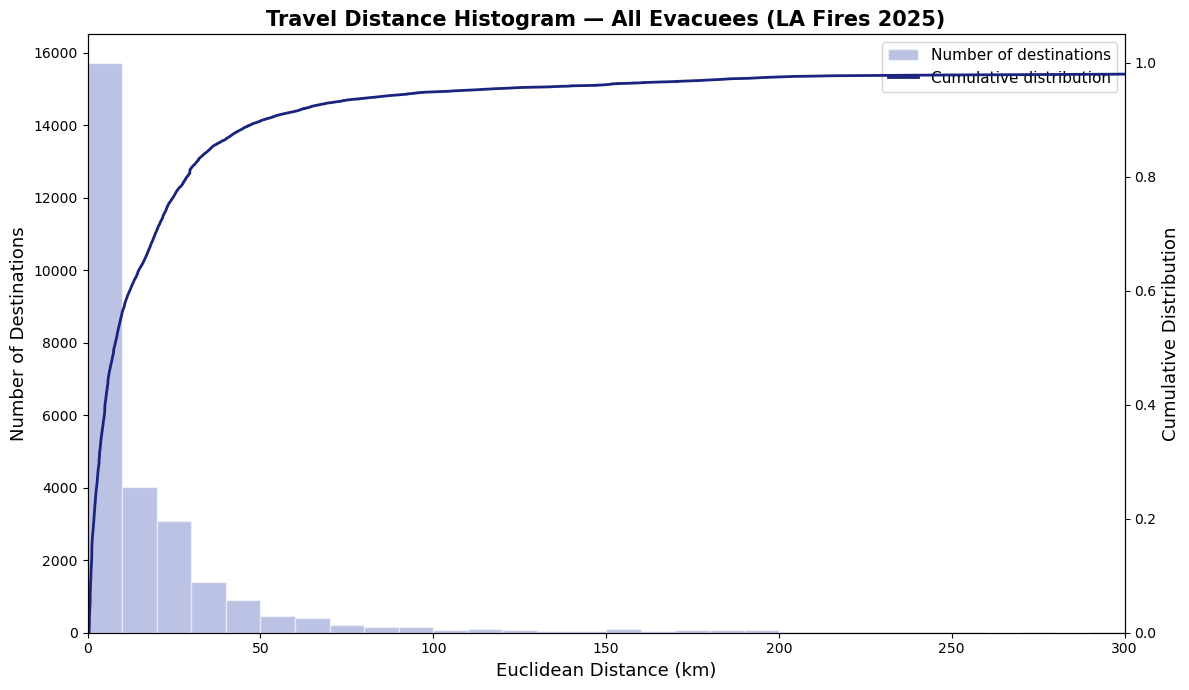

In [11]:
metrics.plot_distance_histogram(
    dest_with_cat,
    max_km=300,
    bin_width=10,
    title='Travel Distance Histogram — All Evacuees (LA Fires 2025)'
)

### 4.2 Distance Histogram + CDF by Group

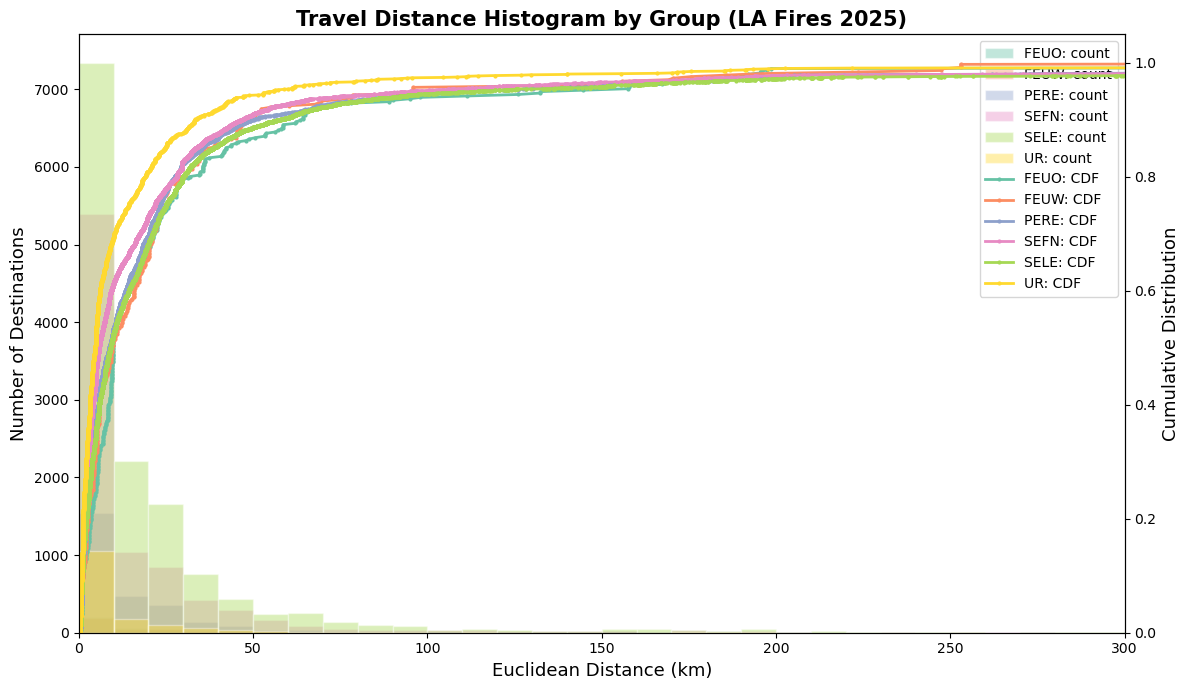

In [12]:
metrics.plot_distance_histogram(
    dest_with_cat,
    group_col='Category',
    max_km=300,
    bin_width=10,
    title='Travel Distance Histogram by Group (LA Fires 2025)'
)

### 4.3 Distance-Decay Curves by Group

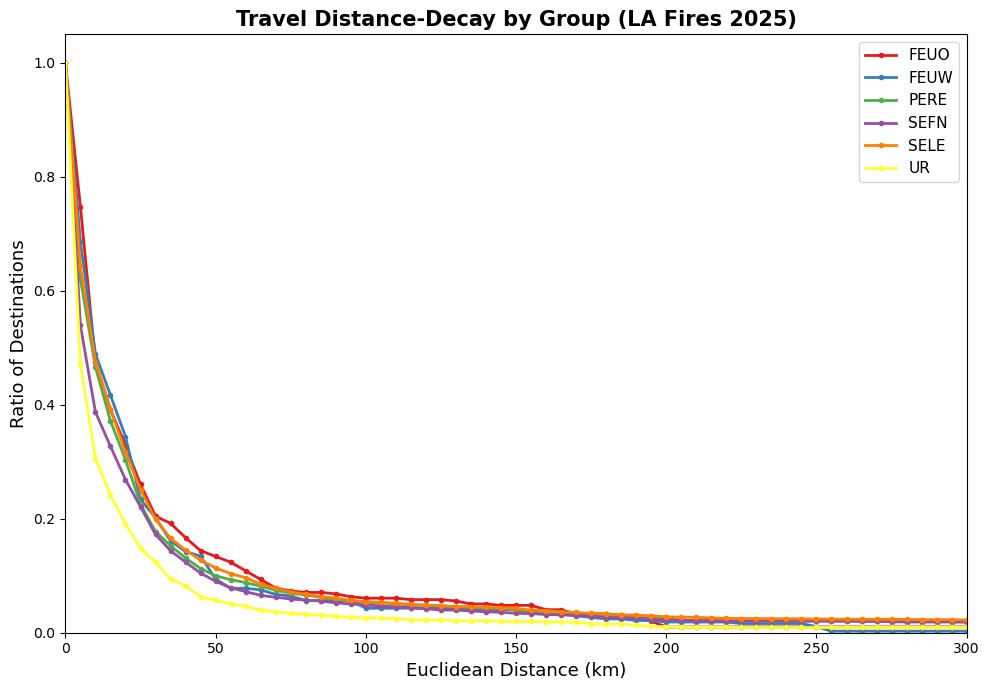

In [13]:
metrics.plot_distance_decay(
    dest_with_cat,
    group_col='Category',
    max_km=300,
    title='Travel Distance-Decay by Group (LA Fires 2025)'
)

---
## 5. Evacuee Groups and Destination Summary

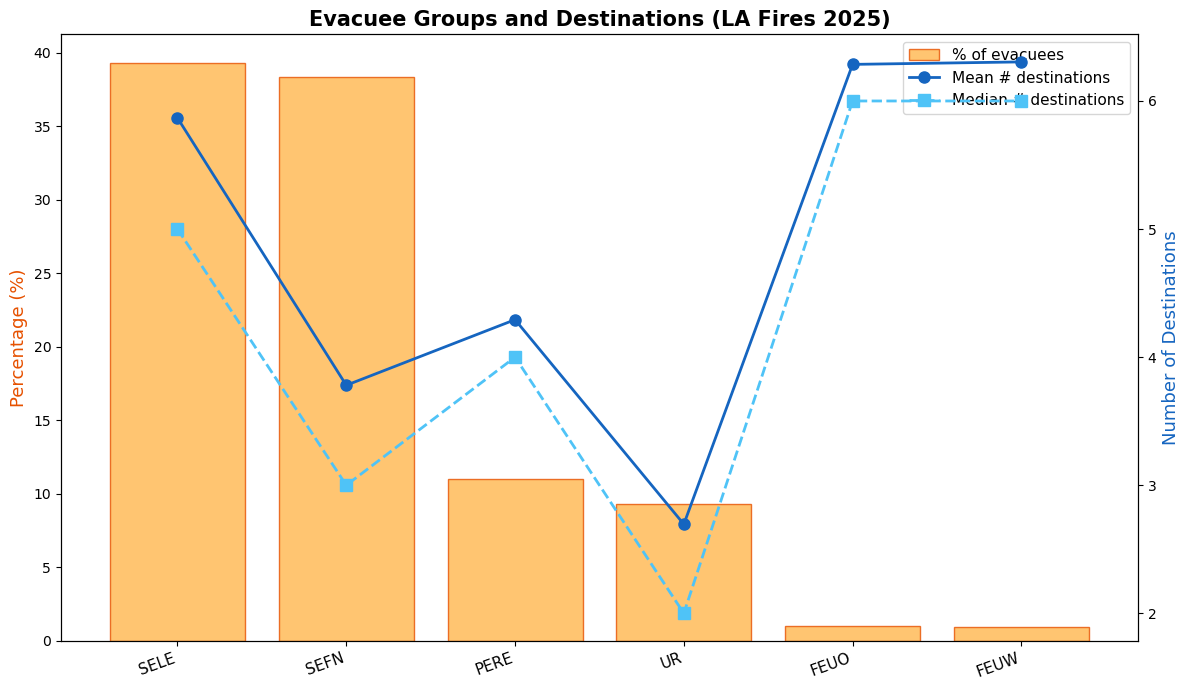

In [14]:
metrics.plot_evacuee_group_summary(
    dest_with_cat,
    group_col='Category',
    title='Evacuee Groups and Destinations (LA Fires 2025)'
)

### 5.1 Number of Destinations per Evacuee

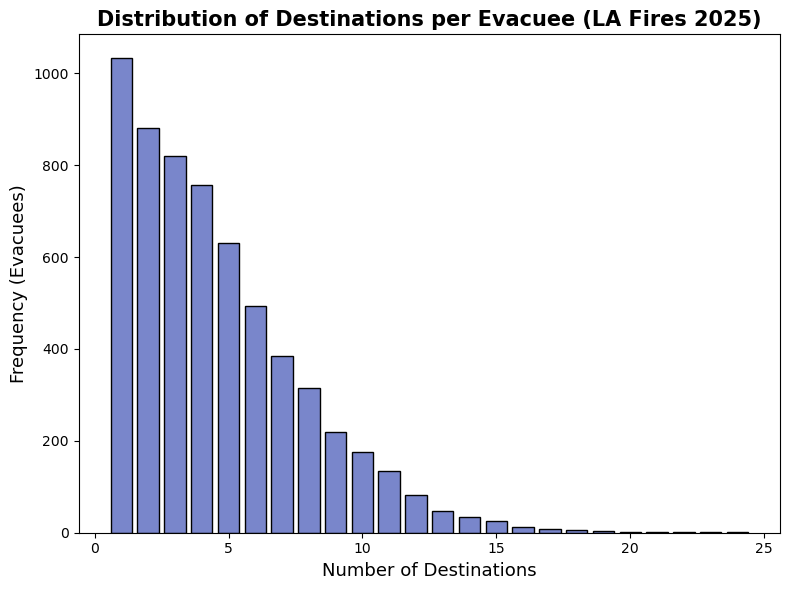

In [15]:
metrics.plot_destination_count(
    dest_with_cat,
    title='Distribution of Destinations per Evacuee (LA Fires 2025)'
)

---
## 6. Destination Type Classification (Optional: Parcel Data)

If county parcel/land-use data is available, the destination types can be classified. This section demonstrates both paths.

> **Note:** If you do not have parcel data, skip to Section 7.

In [16]:
PARCEL_PATH = 'data/LA_County/General_Plan_Land_Use/General_Plan_Land_Use.shp'
ROADS_PATH  = 'data/LA_County/tl_2025_06037_roads/tl_2025_06037_roads.shp'

# Load parcel data
parcels = None
if PARCEL_PATH and os.path.exists(PARCEL_PATH):
    parcels = io.load_parcels(PARCEL_PATH, type_col='GENERALIZE')
    print(f"Loaded {len(parcels):,} parcels")
else:
    print("No parcel data available — destination types will not be classified.")
    print("To enable type classification, set PARCEL_PATH above.")

# Load road centerline data (TIGER/Line)
import geopandas as gpd
roads = None
if ROADS_PATH and os.path.exists(ROADS_PATH):
    roads = gpd.read_file(ROADS_PATH)
    print(f"Loaded {len(roads):,} road segments")
else:
    print("No road data available — road classification will be skipped.")


Loaded 52,330 parcels
Loaded 121,296 road segments


In [17]:
# Classify destinations using parcel data + road geometry
dest_classified = destination.classify_destinations(
    dest_with_cat,
    parcels=parcels,
    roads=roads,
    type_col='GENERALIZE',
    dest_lat_col='dest_lat',
    dest_lon_col='dest_lon',
)

print("Destination type distribution:")
print(dest_classified['dest_type'].value_counts(dropna=False))


Destination type distribution:
dest_type
unknown        15603
road            4797
residential     4043
open space      1320
commercial      1303
public           509
industrial       329
other             58
Name: count, dtype: int64


### 6.1 Destination Types — All Destinations

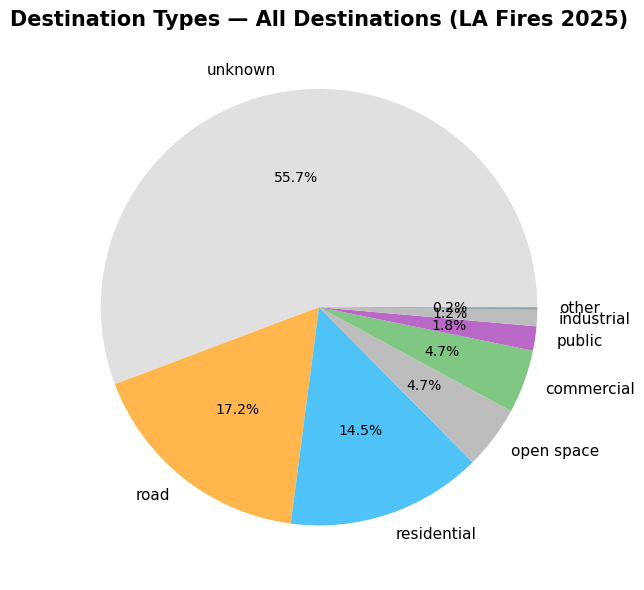

In [18]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        title='Destination Types — All Destinations (LA Fires 2025)'
    )
else:
    print("Skipping: No parcel data — destination types are not classified.")

### 6.2 Destination Types: ≤30 km

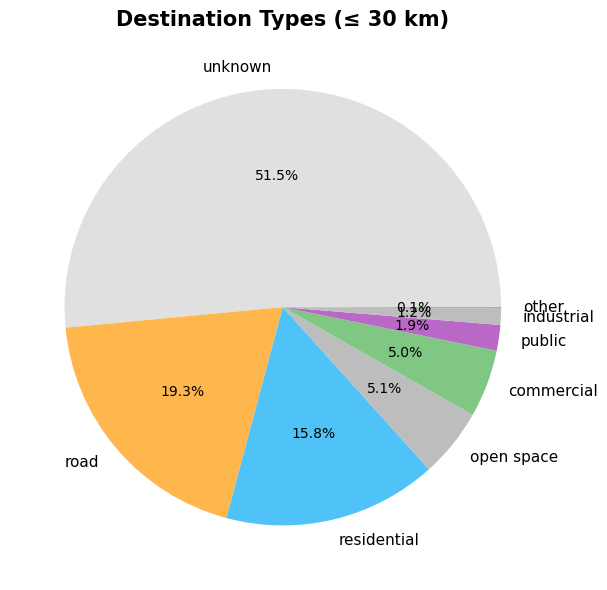

In [19]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        distance_threshold=30, threshold_mode='leq',
        title='Destination Types (≤ 30 km)'
    )
else:
    print("Skipping: No parcel data.")

### 6.3 Destination Types: >30 km

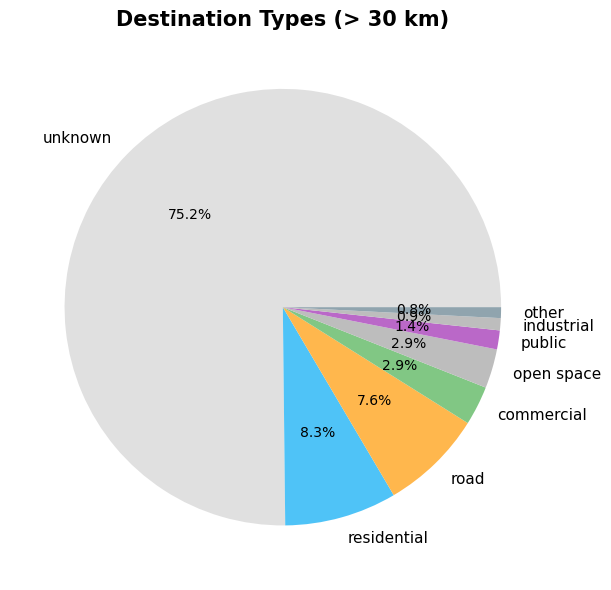

In [20]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        distance_threshold=30, threshold_mode='gt',
        title='Destination Types (> 30 km)'
    )
else:
    print("Skipping: No parcel data.")

### 6.4 Comparison: ≤30 km vs >30 km

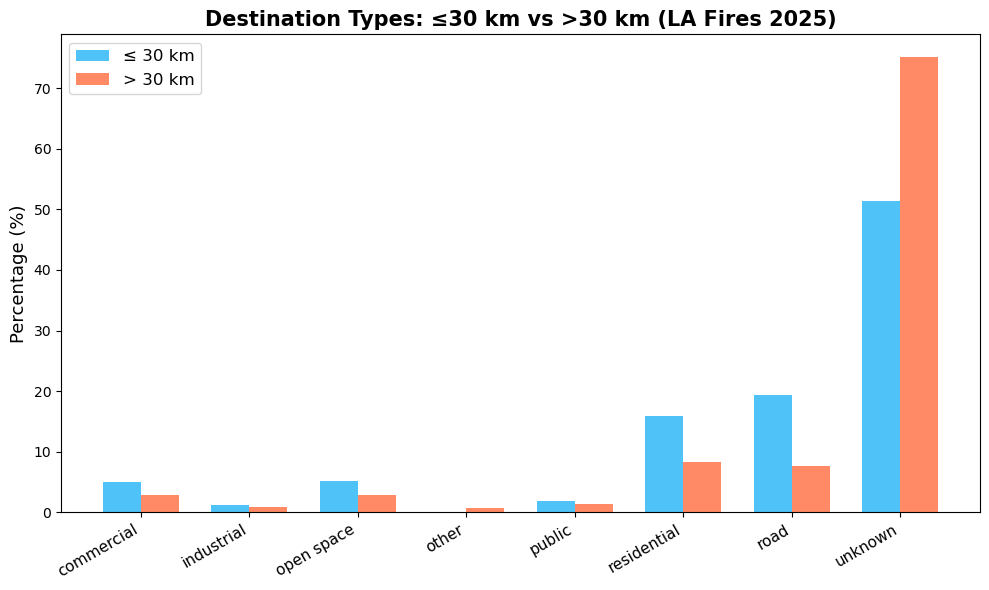

In [21]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_dest_type_comparison(
        dest_classified,
        threshold_km=30,
        title='Destination Types: ≤30 km vs >30 km (LA Fires 2025)'
    )
else:
    print("Skipping: No parcel data.")

### 6.5 Group × Destination Type: Percent of Trips

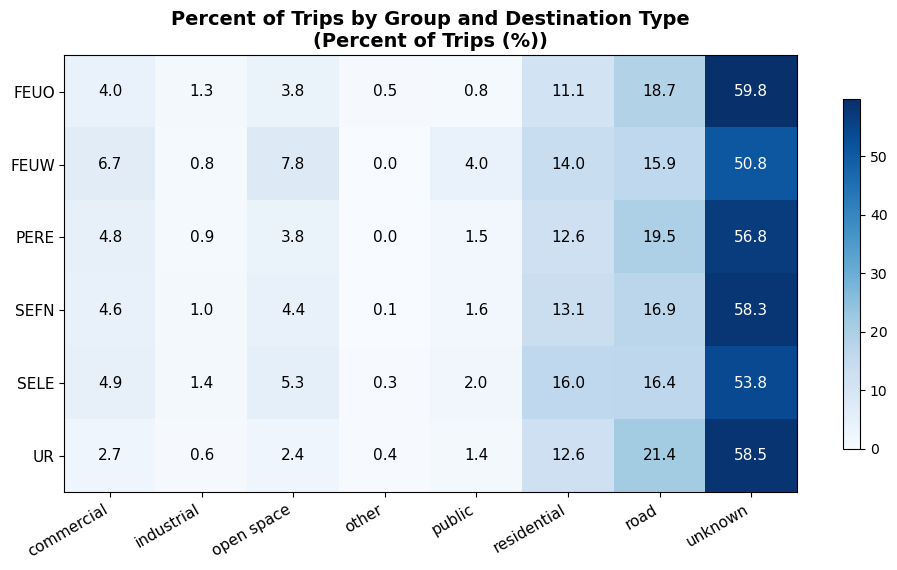

In [22]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_group_dest_heatmap(
        dest_classified,
        group_col='Category',
        metric='pct',
        title='Percent of Trips by Group and Destination Type'
    )
else:
    print("Skipping: No parcel data.")

### 6.6 Group × Destination Type: Median Distance

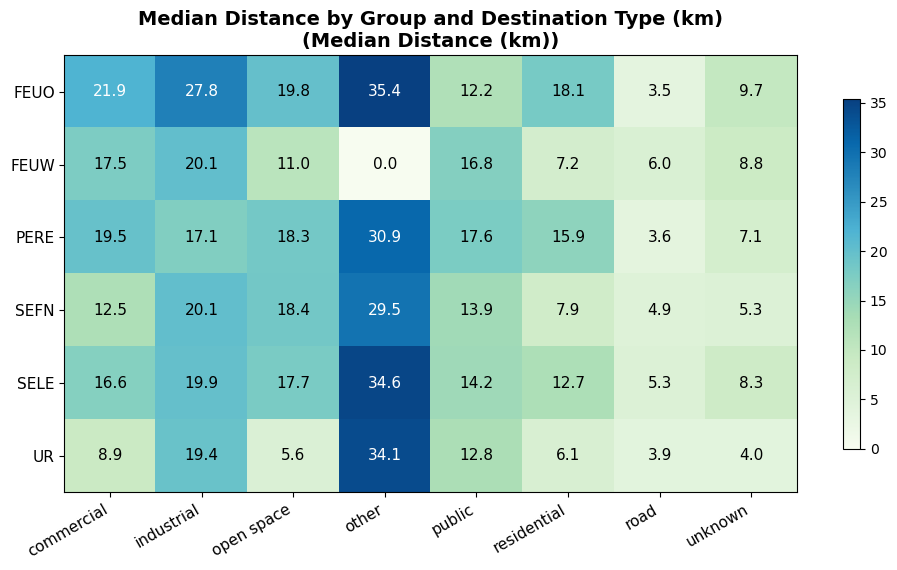

In [23]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_group_dest_heatmap(
        dest_classified,
        group_col='Category',
        metric='median_distance',
        title='Median Distance by Group and Destination Type (km)'
    )
else:
    print("Skipping: No parcel data.")

---
## 7. Origin-Destination Maps

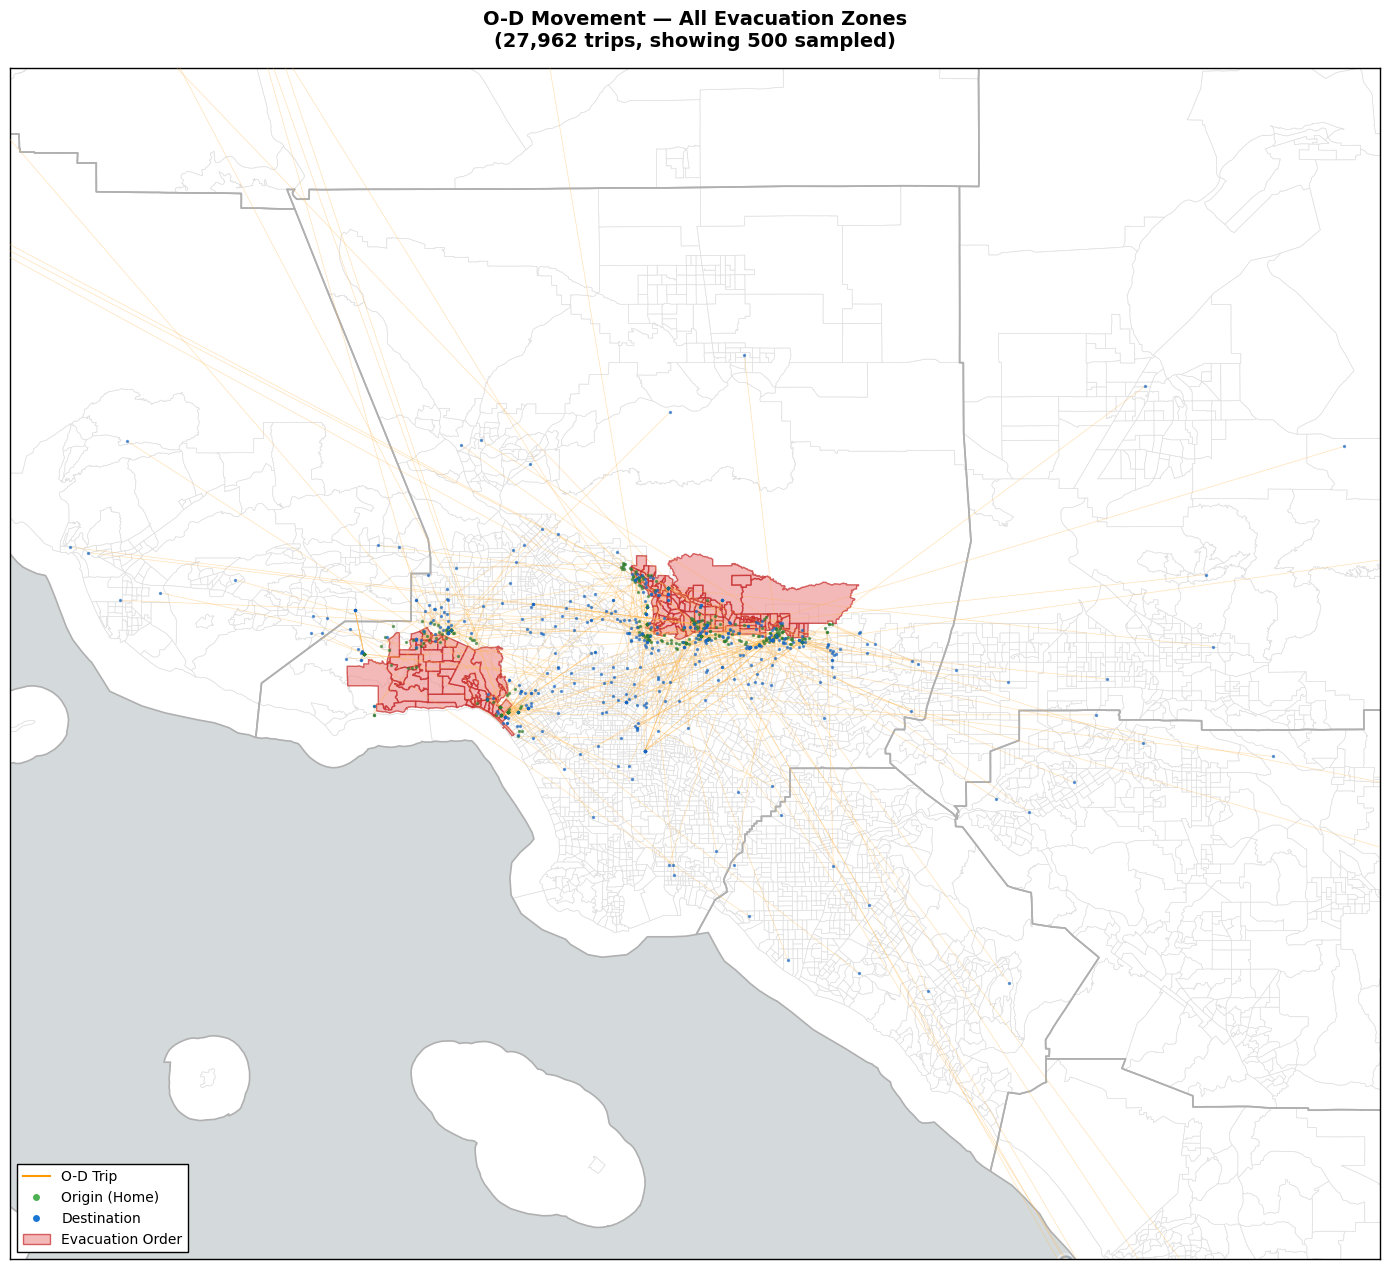

In [24]:
# Separate zones by status
order_zones = fire_zones[fire_zones['status'] == 'Order'] if 'status' in fire_zones.columns else fire_zones
warning_zones = fire_zones[fire_zones['status'] == 'Warning'] if 'status' in fire_zones.columns else None

# Optional census tract background for paper-style geographic borders
census_tracts = None
try:
    census_tracts = gpd.read_file('data/tls/tl_2023_06_tract.shp')
except Exception:
    pass

if not dest_classified.empty:
    metrics.plot_od_map(
        dest_classified,
        order_zones=order_zones,
        warning_zones=warning_zones,
        title='O-D Movement — All Evacuation Zones',
        census_tracts=census_tracts,
        xlim=(-119.4, -116.9),
        ylim=(33.2, 35.0),
        zoom_percentile=98.5,
        max_trips=500,
    )


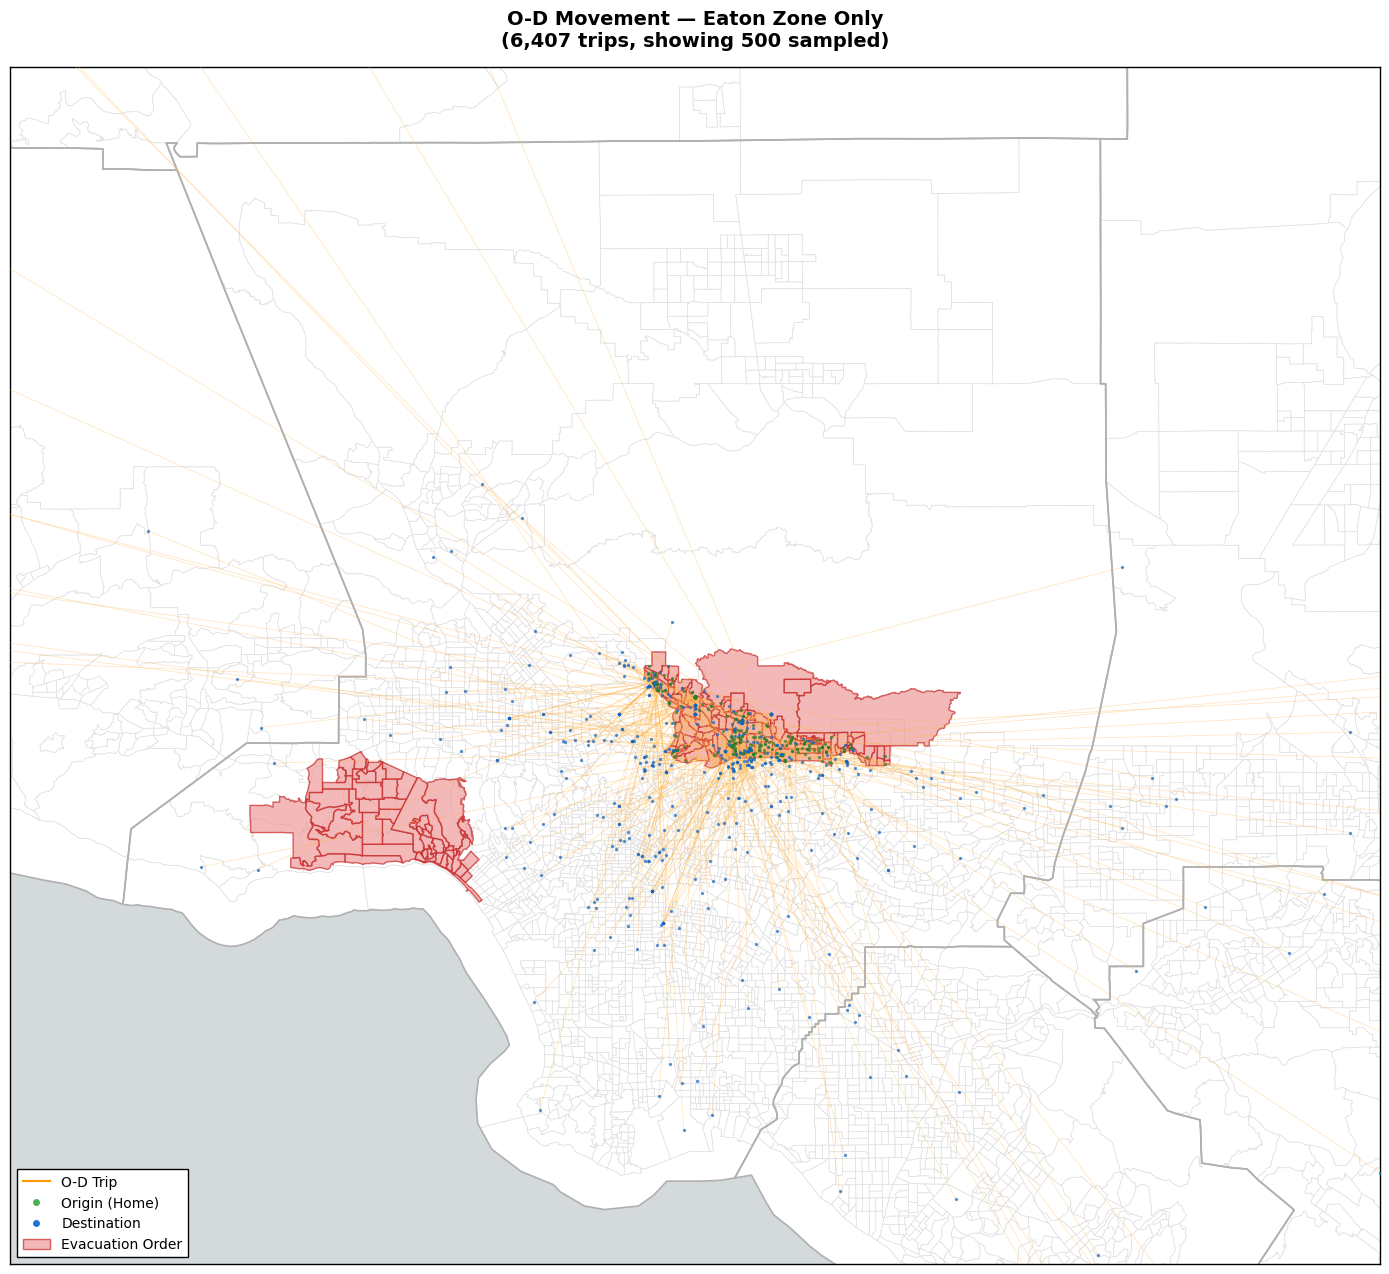

In [25]:
# Filter Eaton zones
eaton_zones = fire_zones[fire_zones['NAME'].str.contains('Eaton', case=False, na=False)] \
    if 'NAME' in fire_zones.columns else fire_zones

eaton_order = eaton_zones[eaton_zones['status'] == 'Order'] if 'status' in eaton_zones.columns else eaton_zones
eaton_warning = eaton_zones[eaton_zones['status'] == 'Warning'] if 'status' in eaton_zones.columns else None

eaton_pings = dest_classified[dest_classified['FireEvent'].str.contains('Eaton', case=False, na=False)]

if not eaton_pings.empty:
    metrics.plot_od_map(
        eaton_pings,
        order_zones=eaton_order,
        warning_zones=eaton_warning,
        title='O-D Movement — Eaton Zone Only',
        census_tracts=census_tracts,
        xlim=(-119.1, -117.3),
        ylim=(33.6, 34.9),
        zoom_percentile=98,
        max_trips=500,
    )


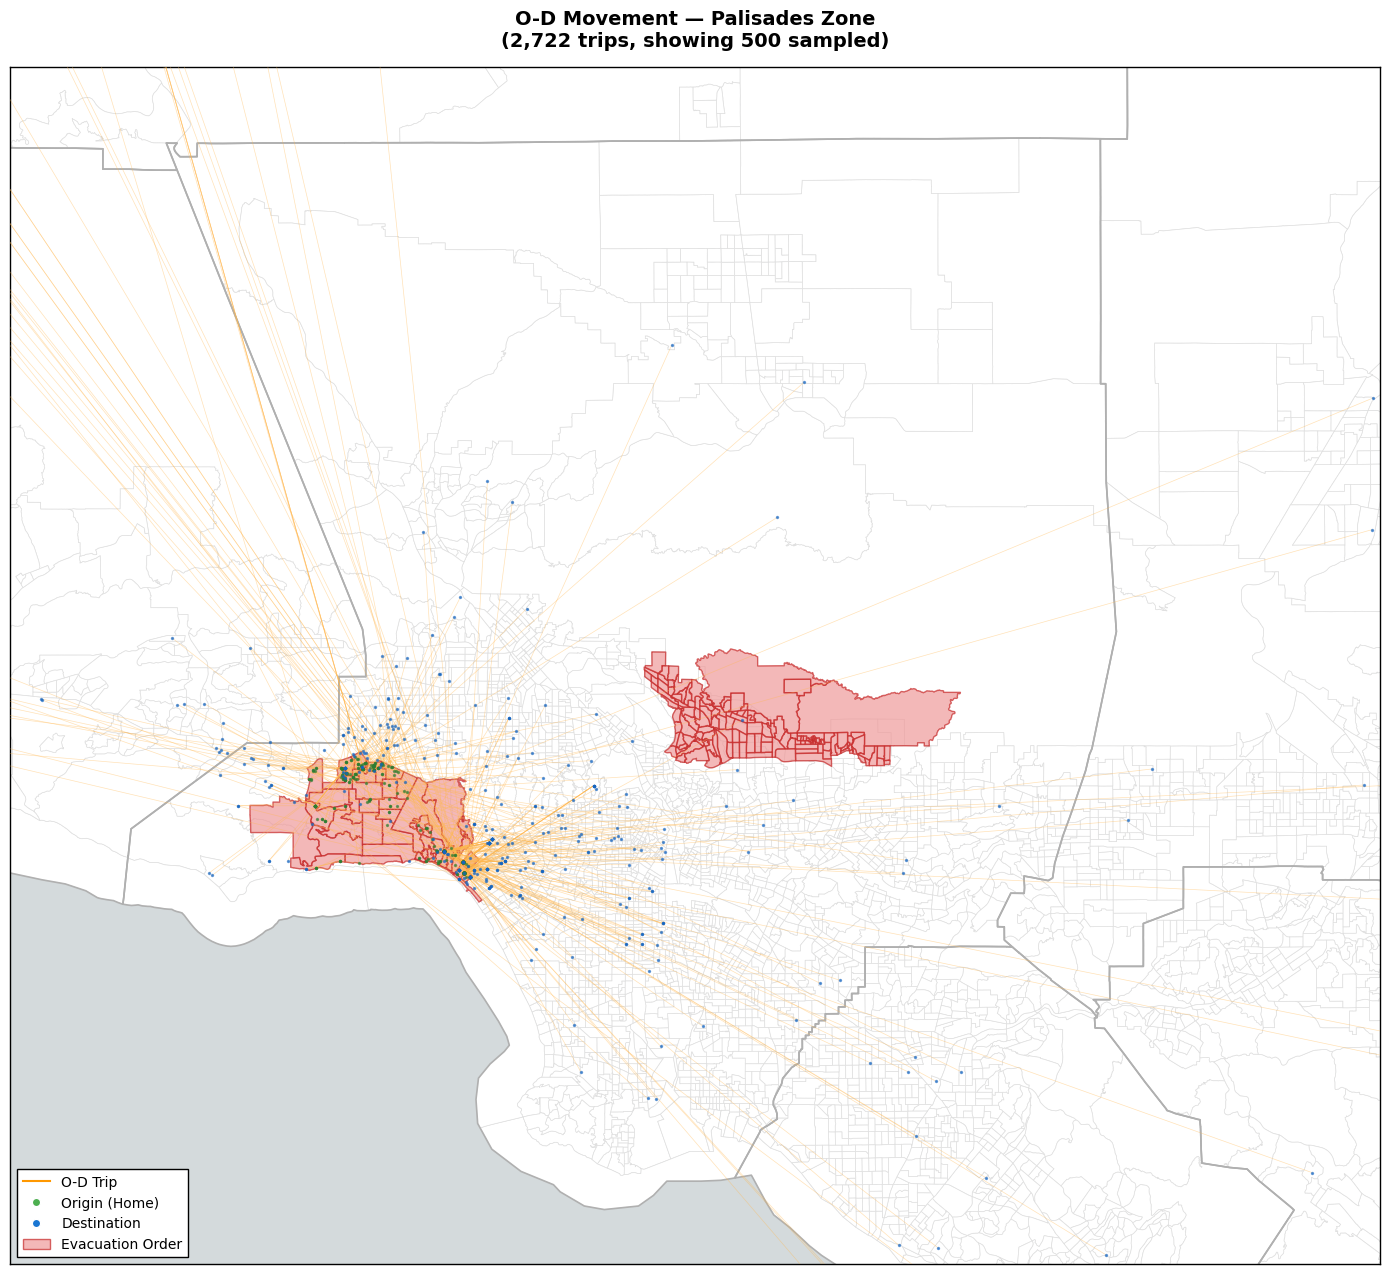

In [26]:
# Filter Palisades zones
palisades_zones = fire_zones[fire_zones['NAME'].str.contains('Palisades', case=False, na=False)] \
    if 'NAME' in fire_zones.columns else fire_zones

palisades_order = palisades_zones[palisades_zones['status'] == 'Order'] if 'status' in palisades_zones.columns else palisades_zones
palisades_warning = palisades_zones[palisades_zones['status'] == 'Warning'] if 'status' in palisades_zones.columns else None

palisades_pings = dest_classified[dest_classified['FireEvent'].str.contains('Palisades', case=False, na=False)]

if not palisades_pings.empty:
    metrics.plot_od_map(
        palisades_pings,
        order_zones=palisades_order,
        warning_zones=palisades_warning,
        title='O-D Movement — Palisades Zone',
        census_tracts=census_tracts,
        xlim=(-119.1, -117.3),
        ylim=(33.6, 34.9),
        zoom_percentile=98,
        max_trips=500,
    )


In [27]:
# Quick O-D distance diagnostics (helps interpret map shape)
from ember.mobility.clustering import haversine_m

od_diag = dest_classified.dropna(subset=['home_lat_4326', 'home_lon_4326', 'dest_lat', 'dest_lon']).copy()
od_diag['od_km'] = od_diag.apply(
    lambda r: haversine_m(r['home_lat_4326'], r['home_lon_4326'], r['dest_lat'], r['dest_lon']) / 1000,
    axis=1,
)

print('Overall O-D distance (km) quantiles:')
print(od_diag['od_km'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

print('\nBy fire event (median / p90 / p99):')
print(
    od_diag.groupby('FireEvent')['od_km']
    .quantile([0.5, 0.9, 0.99])
    .unstack()
    .round(2)
    .rename(columns={0.5: 'p50_km', 0.9: 'p90_km', 0.99: 'p99_km'})
)

print('\nTop 10 longest trips (sanity check):')
display(
    od_diag.sort_values('od_km', ascending=False)
    [['ID', 'FireEvent', 'home_lat_4326', 'home_lon_4326', 'dest_lat', 'dest_lon', 'od_km']]
    .head(10)
)


Overall O-D distance (km) quantiles:
0.50      7.68
0.75     23.24
0.90     50.86
0.95    104.16
0.99    499.30
Name: od_km, dtype: float64

By fire event (median / p90 / p99):
           p50_km  p90_km  p99_km
FireEvent                        
Eaton       10.65   60.29  480.73
Palisades    8.94   70.68  529.03

Top 10 longest trips (sanity check):


,ID,FireEvent,home_lat_4326,home_lon_4326,dest_lat,dest_lon,od_km
17251,9b252798-e35b-32d4-bc9b-f6ccd5898882,NaN,34.138680,-118.675119,41.761816,-124.224955,976.862481
17254,9b252798-e35b-32d4-bc9b-f6ccd5898882,NaN,34.138680,-118.675119,41.761774,-124.224977,976.859468
17252,9b252798-e35b-32d4-bc9b-f6ccd5898882,NaN,34.138680,-118.675119,41.748795,-124.180305,973.691780
23770,da5caf37-d354-3290-b499-a437762c819c,NaN,34.232930,-118.258988,41.080830,-124.147741,920.630472
24567,e1b5f930-7fdc-3a67-91a7-d0dec58e14cd,NaN,34.148277,-118.001748,40.790133,-124.150919,915.932337
7786,46ef655b-acfa-3b36-96f8-40c7b3e30df7,Eaton,34.157472,-118.230206,40.952060,-124.110745,915.736946
7788,46ef655b-acfa-3b36-96f8-40c7b3e30df7,Eaton,34.157472,-118.230206,40.938535,-124.114614,914.717822
7784,46ef655b-acfa-3b36-96f8-40c7b3e30df7,Eaton,34.157472,-118.230206,40.938528,-124.114573,914.715127
8127,4a3e8a5e-ab1a-3d60-b8c2-e63dd0eb0864,NaN,34.135995,-118.166993,40.687981,-122.375309,817.612790
8129,4a3e8a5e-ab1a-3d60-b8c2-e63dd0eb0864,NaN,34.135995,-118.166993,40.687894,-122.375256,817.602159


---
## 8. Activity-Based Origin Inference

EMBER supports **activity-based origin detection**: instead of assuming all evacuees departed from home, it uses incremental clustering to find where the evacuee actually was at the time the fire started.

This is particularly relevant for rapid-onset wildfires where evacuees may have been at work, shopping, or other activities.

### Hyperparameters
* `R_a`: Spatial radius parameter for location clustering (meters)
* `T_a`: Duration threshold for an activity stop (e.g., '5min')
* `home_radius`: Distance threshold to classify an origin as 'home' (meters)
* `max_origin_distance`: Maximum distance to search for an origin prior to evacuation (meters)


In [28]:
# Hyperparameters for activity-based origin inference
R_a = 200.0
T_a = "5min"
home_radius = 200.0
max_origin_distance = 50000.0

In [29]:
from ember.activities import find_origin

# Build a home-location lookup for quick origin inference
home_lookup = {
    row['ID']: (row['home_lat_4326'], row['home_lon_4326'])
    for _, row in homes.dropna(subset=['home_lat_4326', 'home_lon_4326']).iterrows()
}

# Pick a sample of evacuees to demonstrate activity-based origin
sample_ids = dau_evac['ID'].unique()[:50]  # first 50 evacuees

# Fire start times for both fires
fire_starts = {
    'Palisades': pd.Timestamp('2025-01-07 10:30:00', tz='US/Pacific'),
    'Eaton': pd.Timestamp('2025-01-07 18:15:00', tz='US/Pacific'),
}

origins = []
for uid in sample_ids:
    if uid not in home_lookup:
        continue
    
    h_lat, h_lon = home_lookup[uid]
    user_pings = dau_evac[dau_evac['ID'] == uid]
    
    # Use the earliest fire start as reference
    fire_start = fire_starts['Palisades'].tz_convert('UTC')
    
    o_lat, o_lon, o_type = find_origin(
        user_pings, h_lat, h_lon,
        fire_start=fire_start,
        R_a=R_a, 
        T_a=T_a, 
        home_radius=home_radius,
        max_origin_distance_m=max_origin_distance
    )

    
    origins.append({
        'ID': uid,
        'origin_lat': o_lat, 'origin_lon': o_lon,
        'origin_type': o_type,
        'home_lat': h_lat, 'home_lon': h_lon,
    })

origins_df = pd.DataFrame(origins)
print(f"Origins inferred: {len(origins_df)}")
print(f"\nOrigin type breakdown:")
print(origins_df['origin_type'].value_counts())

Origins inferred: 50

Origin type breakdown:
origin_type
home        43
activity     7
Name: count, dtype: int64


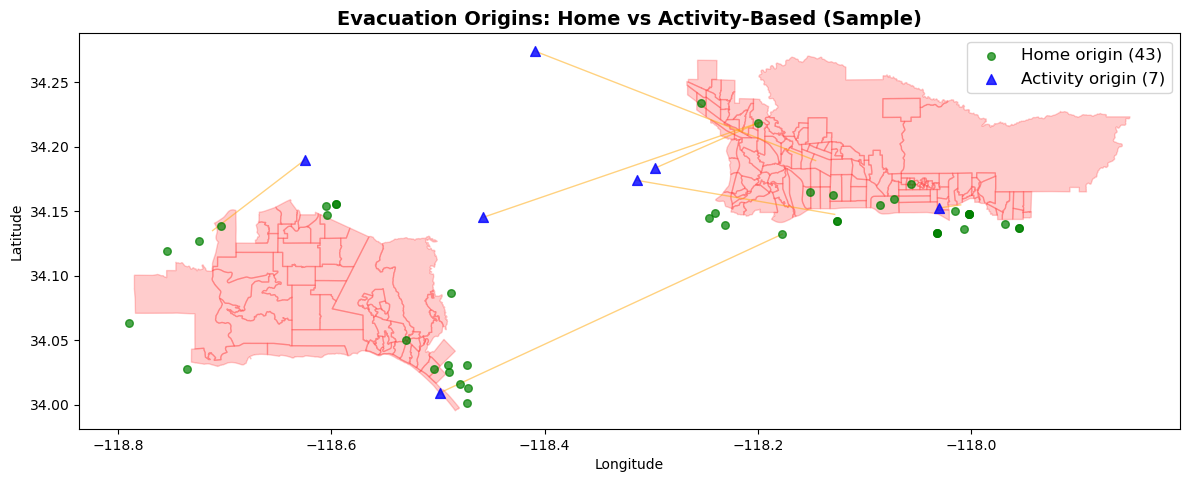

In [30]:
# Visualize: Home vs Activity origins on a map
try:
    import geopandas as gpd
    from shapely.geometry import Point
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot fire zones
    fire_zones.to_crs('EPSG:4326').plot(ax=ax, color='red', alpha=0.2, edgecolor='red')
    
    # Plot origins
    home_origins = origins_df[origins_df['origin_type'] == 'home']
    act_origins = origins_df[origins_df['origin_type'] == 'activity']
    
    if not home_origins.empty:
        ax.scatter(home_origins['origin_lon'], home_origins['origin_lat'],
                  c='green', s=30, alpha=0.7, label=f'Home origin ({len(home_origins)})', zorder=3)
    if not act_origins.empty:
        ax.scatter(act_origins['origin_lon'], act_origins['origin_lat'],
                  c='blue', s=50, marker='^', alpha=0.8, label=f'Activity origin ({len(act_origins)})', zorder=4)
        # Draw lines from home to activity origin
        for _, row in act_origins.iterrows():
            ax.plot([row['home_lon'], row['origin_lon']],
                   [row['home_lat'], row['origin_lat']],
                   color='orange', alpha=0.5, linewidth=1)
    
    ax.legend(fontsize=12)
    ax.set_title('Evacuation Origins: Home vs Activity-Based (Sample)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Map plotting requires geopandas: {e}")

---
## 9. K-S Test: Distance Distribution Comparison

Kolmogorov-Smirnov tests comparing travel-distance distributions between all pairs of evacuee groups. The heatmap shows KS statistics with significance stars.

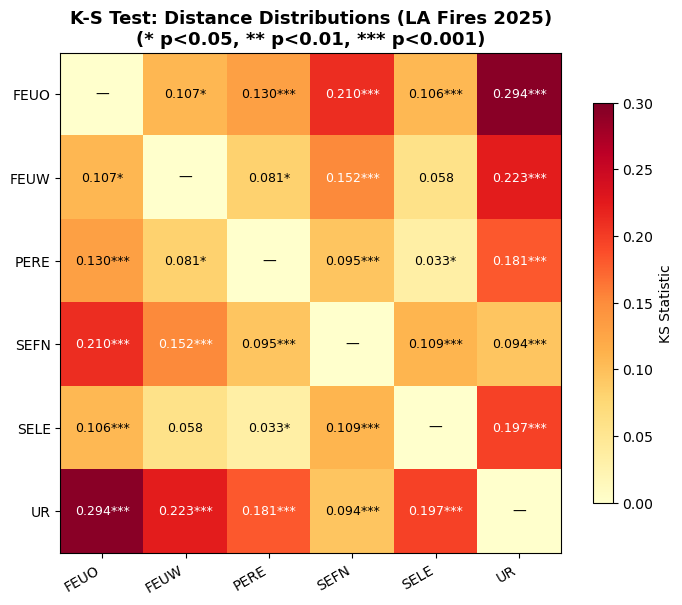

,Group_A,Group_B,KS_Statistic,p_value,Significant (p<0.05),n_A,n_B
0,FEUO,FEUW,0.1072,0.022077,True,396,372
1,FEUO,PERE,0.1301,0.000013,True,396,2876
2,FEUO,SEFN,0.2099,0.000000,True,396,8801
3,FEUO,SELE,0.1062,0.000309,True,396,13994
4,FEUO,UR,0.2937,0.000000,True,396,1523
5,FEUW,PERE,0.0810,0.024893,True,372,2876
6,FEUW,SEFN,0.1519,0.000000,True,372,8801
7,FEUW,SELE,0.0582,0.164805,False,372,13994
8,FEUW,UR,0.2232,0.000000,True,372,1523
9,PERE,SEFN,0.0948,0.000000,True,2876,8801


In [31]:
ks_results = metrics.ks_test_distances(
    dest_with_cat,
    group_col='Category',
    title='K-S Test: Distance Distributions (LA Fires 2025)'
)
ks_results

---
## 10. Temporal Destination Analysis

Track how evacuation destinations evolve over the fire timeline — do evacuees move further away or closer to home as the fire progresses?

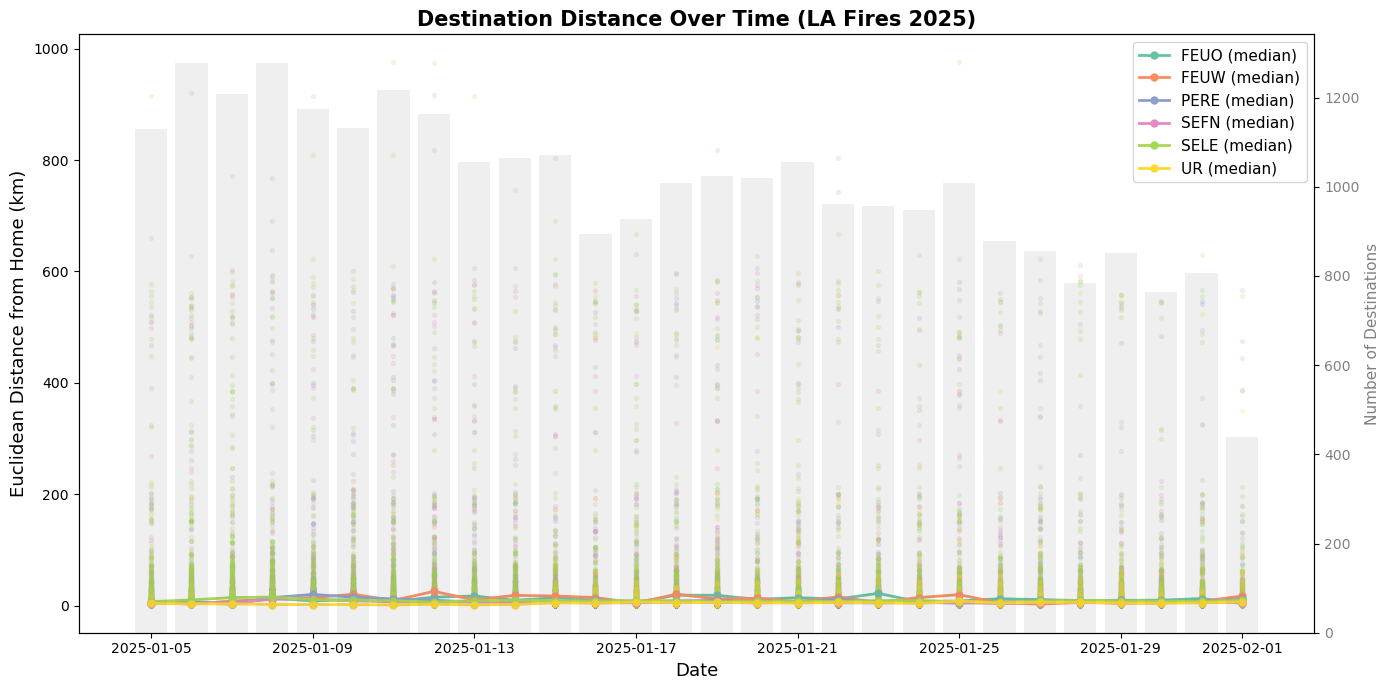

In [32]:
metrics.plot_temporal_destinations(
    dest_with_cat,
    group_col='Category',
    title='Destination Distance Over Time (LA Fires 2025)'
)

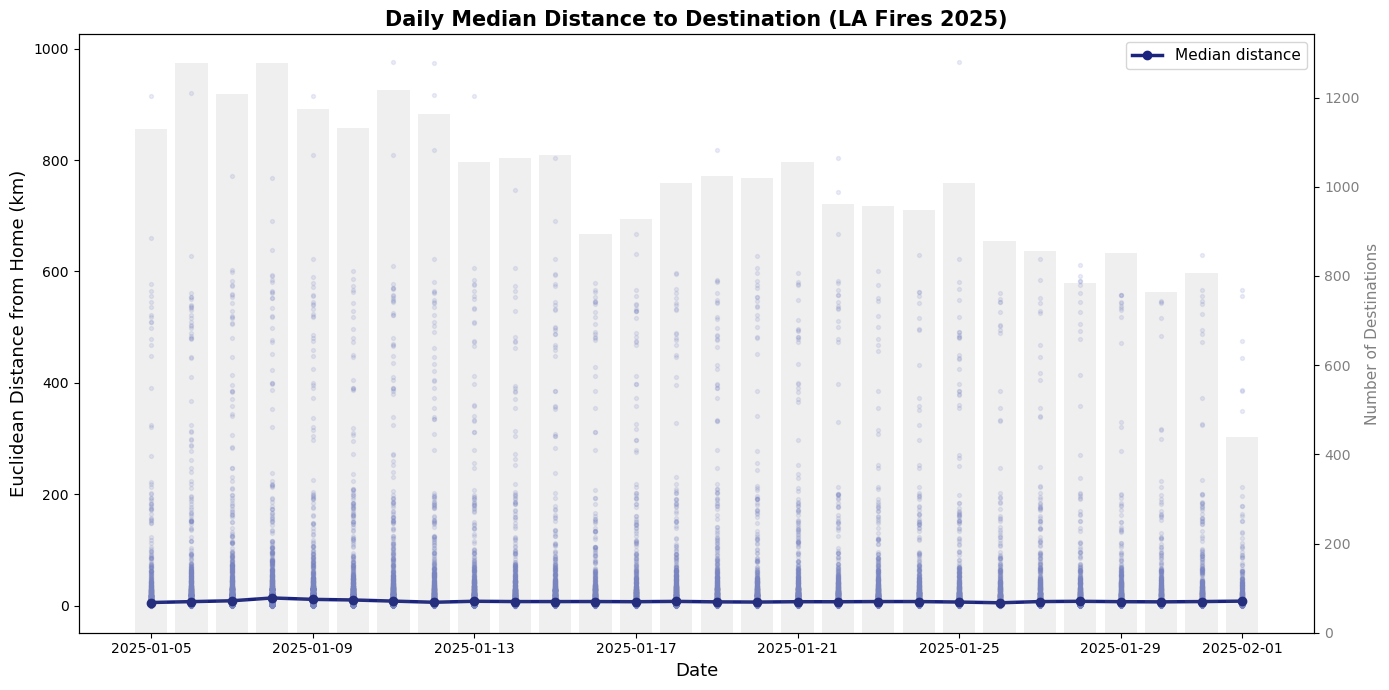

In [33]:
# Overall (without group breakdown)
metrics.plot_temporal_destinations(
    dest_with_cat,
    title='Daily Median Distance to Destination (LA Fires 2025)'
)

---
## 11. Return Behavior by Destination

Analyze the relationship between where evacuees went and when they returned home. Does destination type or distance predict how long evacuees stay away?

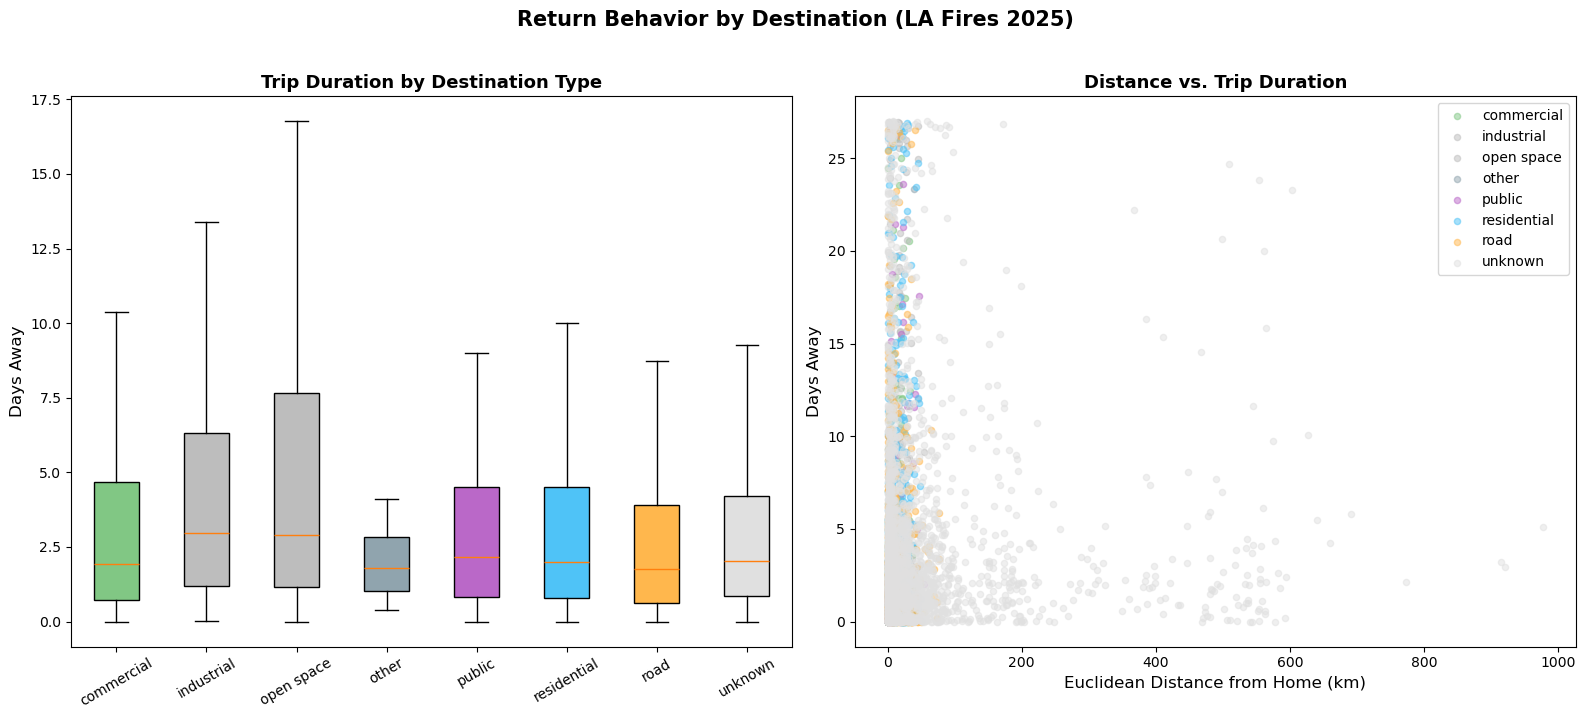

In [34]:
metrics.plot_return_by_destination(
    dest_classified,
    evac_metrics,
    title='Return Behavior by Destination (LA Fires 2025)'
)

---
## 12. Summary Statistics

In [35]:
print("=" * 60)
print("DESTINATION ANALYSIS SUMMARY — LA Wildfires 2025")
print("=" * 60)
print(f"Total evacuees analyzed:       {dest_df['ID'].nunique():,}")
print(f"Total destinations inferred:   {len(dest_df):,}")
print(f"Mean destinations / evacuee:   {dest_df.groupby('ID').size().mean():.2f}")
print(f"Median destinations / evacuee: {dest_df.groupby('ID').size().median():.1f}")
print(f"\nDistance from home (km):")
print(f"  Mean:   {dest_df['eu_distance_km'].mean():.1f}")
print(f"  Median: {dest_df['eu_distance_km'].median():.1f}")
print(f"  Max:    {dest_df['eu_distance_km'].max():.1f}")
print(f"  ≤ 30 km: {(dest_df['eu_distance_km'] <= 30).mean()*100:.1f}%")
print(f"  > 30 km:  {(dest_df['eu_distance_km'] > 30).mean()*100:.1f}%")

DESTINATION ANALYSIS SUMMARY — LA Wildfires 2025
Total evacuees analyzed:       6,070
Total destinations inferred:   27,962
Mean destinations / evacuee:   4.61
Median destinations / evacuee: 4.0

Distance from home (km):
  Mean:   28.3
  Median: 7.7
  Max:    976.9
  ≤ 30 km: 81.6%
  > 30 km:  18.4%


In [36]:
# Distance stats by category
if 'Category' in dest_with_cat.columns:
    print("\nDistance by Category:")
    print(dest_with_cat.groupby('Category')['eu_distance_km'].agg(['count', 'mean', 'median', 'max']).round(1))


Distance by Category:
          count  mean  median    max
Category                            
FEUO        396  28.8     9.9  514.9
FEUW        372  24.8     9.7  531.7
PERE       2876  28.1     8.8  742.2
SEFN       8801  26.2     5.9  915.9
SELE      13994  31.0     9.1  976.9
UR         1523  17.2     4.6  562.9
